<img src="https://sfudial.ca/wp-content/uploads/SFU-DIAL-Logo.png" width=40%>&nbsp;&nbsp;&nbsp;&nbsp;<img src="https://www.sfu.ca/content/dam/sfu/images/brand_extension/SFU-Big-Data_Logo.png" width=40%>

# Lab 4.1: Detecting Anomalies with AI

Learn how to use AI-powered tools to detect anomalies in real-world datasets. Explore different anomaly detection techniques and understand when to apply each approach for maximum effectiveness.

**Use the TODOs and prompt your AI like a teammate. Think critically, experiment often, and document your process.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/gist/git-steb/aefa0f766e56dcbbe0bacdc607fdaa4a/4_1_Detecting_Anomalies_with_AI.ipynb)

## Lab Outline

- **Part 1:** Set up your environment and load datasets
- **Part 2:** Explore traditional anomaly detection methods
- **Part 3:** Apply AI-enhanced anomaly detection
- **Part 4:** Compare approaches and interpret results
- **Deliverable:** Reflection on AI-assisted anomaly detection

## Getting Help from Your AI Assistant

**Why AI assistance matters:** AI tools can help you understand complex anomaly detection algorithms, suggest appropriate techniques for your data, and interpret results effectively. They're particularly valuable for learning when to use different approaches.

**Good prompts:**
- "Help me understand what makes this data point an anomaly"
- "What anomaly detection method would work best for this type of data?"
- "How can I validate that these anomalies are real and not noise?"
- "What would an expert look for when detecting anomalies?"
- "Help me interpret these anomaly scores"
- "How can I reduce false positives in my anomaly detection?"

**Avoid vague prompts like "find anomalies"**

**Pro Tip:** Ask "what would a data scientist look for" and "how should I validate these results" to get more targeted assistance.

## Learning Objectives

By the end of this lab, you will be able to:
- [ ] **Set up and configure** AI-enhanced anomaly detection environments with proper data preprocessing
- [ ] **Compare and contrast** traditional statistical methods vs. AI-powered approaches for anomaly detection
- [ ] **Apply machine learning techniques** (Isolation Forest, DBSCAN, Autoencoders) to detect anomalies in real datasets
- [ ] **Interpret and validate** anomaly detection results to distinguish between real anomalies and noise
- [ ] **Choose appropriate methods** based on data characteristics and business requirements
- [ ] **Build practical skills** for detecting fraud, system failures, and unusual patterns in professional contexts

## Why Anomaly Detection Matters in the Real World

**Anomaly detection is crucial for business success** because it helps identify:
- **Financial fraud** in credit card transactions and banking systems
- **System failures** in manufacturing equipment and IT infrastructure  
- **Security breaches** in network traffic and user behavior
- **Quality issues** in production processes and supply chains

**Why AI makes a difference:** Traditional rule-based systems miss complex, evolving patterns. AI can learn from data to detect subtle anomalies that humans and simple algorithms would miss, potentially saving millions in fraud prevention and system reliability.

## Lab Structure
  1. **Setup & Preparation** - Environment setup and data loading
  2. **Traditional Methods** - Statistical and distance-based approaches
  3. **AI-Enhanced Detection** - Machine learning and deep learning methods
  4. **Comparison & Validation** - Comparing approaches and validating results
  5. **Reflection** - Understanding when to use each approach

## Part 1: Environment Setup

### Step 1: Install Required Packages

In [1]:
# Install required packages
# !pip install  # Double-commented for safety. Remove both # to install. --quiet pandas numpy scikit-learn matplotlib seaborn plotly

# !pip install pandas numpy scikit-learn matplotlib seaborn plotly

### Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

### Step 3: Load Your Dataset

**🎯 Hands-on Practice:** This notebook uses the employee expense claims dataset (`employee_expense_claims_with_pii.csv`) for anomaly detection. Numerical features (e.g. claim amount, expenses, receipt diff) are used to detect potentially fraudulent or unusual claims.

In [ ]:
# Load employee expense claims dataset for anomaly detection
# Numerical features (excluding PII) used for detection
df = pd.read_csv('..data/employee_expense_claims_with_pii.csv')

# Core numerical features for anomaly detection
# We focus on financial/behavioral features that carry the strongest signal.
# Binary or low-variance columns (is_weekend_claim, num_prior_approvals,
# years_employed) are excluded to reduce noise in high-dimensional space.
feature_cols = [
    'annual_income', 'claim_amount', 'num_items_claimed',
    'days_since_last_claim', 'meal_expense', 'travel_expense',
    'lodging_expense', 'receipt_vs_claim_diff'
]

# Prepare feature matrix (fill missing values with median)
X = df[feature_cols].fillna(df[feature_cols].median())

# Scale features for anomaly detection methods
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add 2D PCA components for visualization (so scatter plots work)
pca_vis = PCA(n_components=2)
pca_2d = pca_vis.fit_transform(X_scaled)
df['feature_1'] = pca_2d[:, 0]
df['feature_2'] = pca_2d[:, 1]

# is_anomaly already exists in the CSV (0 = normal, 1 = anomaly)
print("Employee expense claims dataset loaded")
print(f"Dataset shape: {df.shape}")
print(f"Anomalies (ground truth): {df['is_anomaly'].sum()}")
print(f"Normal claims: {(df['is_anomaly'] == 0).sum()}")
print(f"Features used: {feature_cols}")

Employee expense claims dataset loaded
Dataset shape: (100, 24)
Anomalies (ground truth): 8
Normal claims: 92
Features used: ['annual_income', 'claim_amount', 'num_items_claimed', 'days_since_last_claim', 'meal_expense', 'travel_expense', 'lodging_expense', 'receipt_vs_claim_diff']


## Part 2: Traditional Anomaly Detection Methods

### Step 1: Statistical Methods

### Statistical Anomaly Detection

**Methods to implement:**
1. Z-score method
2. Interquartile Range (IQR) method  
3. Modified Z-score method

In [4]:
# TODO: Implement statistical anomaly detection

# Z-score method (on scaled numerical features)
# Points where any feature exceeds 3 standard deviations are flagged
from scipy import stats
z_scores = np.abs(stats.zscore(X_scaled))
anomaly_threshold = 3
statistical_anomalies = (z_scores > anomaly_threshold).any(axis=1)

print(f"\nStatistical anomalies detected: {statistical_anomalies.sum()}")


Statistical anomalies detected: 7


### Step 2: Distance-Based Methods

### Distance-Based Anomaly Detection

**Methods to implement:**
1. K-Nearest Neighbors (KNN)
2. Local Outlier Factor (LOF)
3. DBSCAN clustering

In [5]:
# TODO: Implement distance-based anomaly detection

# DBSCAN for anomaly detection (on scaled features)
# Note: eps controls neighborhood radius — too small flags too many points
# as noise. With 8 features, eps=2.0 works well. Try different values!
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Points labeled as -1 are considered anomalies
dbscan_anomalies = dbscan_labels == -1
print(f"\nDBSCAN anomalies detected: {dbscan_anomalies.sum()}")


DBSCAN anomalies detected: 7


## Part 3: AI-Enhanced Anomaly Detection

### Step 1: Machine Learning Approaches

### AI-Enhanced Anomaly Detection

**Methods to implement:**
1. Isolation Forest
2. One-Class SVM
3. Autoencoder-based detection
4. Deep learning approaches

In [6]:
# TODO: Implement AI-enhanced anomaly detection

# Isolation Forest (on scaled features)
# contamination = expected proportion of anomalies in the dataset
# Our dataset has 8% anomalies — try changing this to see the effect!
iso_forest = IsolationForest(contamination=0.08, random_state=42)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_anomalies = iso_predictions == -1

print(f"\nIsolation Forest anomalies detected: {iso_anomalies.sum()}")


Isolation Forest anomalies detected: 8


### Step 2: Advanced AI Techniques

**🎯 Hands-on Practice:** Experiment with different AI techniques. Try adjusting parameters and see how they affect detection results.

### Advanced AI Techniques

**Methods to explore:**
1. Autoencoder reconstruction error
2. Variational Autoencoders (VAE)
3. Generative Adversarial Networks (GANs)
4. Transformer-based anomaly detection

In [7]:
# TODO: Explore advanced AI techniques

# AI Prompt: "Help me understand when to use each of these AI techniques
# for anomaly detection. What are the trade-offs?"

# PCA-based anomaly detection (on scaled features)
# Reduce to 2 components, reconstruct, measure error
# High reconstruction error = point doesn't fit the main patterns
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
pca_reconstruction = pca.inverse_transform(pca_data)
reconstruction_error = np.mean((X_scaled - pca_reconstruction) ** 2, axis=1)

# Anomalies are points with high reconstruction error
pca_anomalies = reconstruction_error > np.percentile(reconstruction_error, 92)
print(f"\nPCA-based anomalies detected: {pca_anomalies.sum()}")


PCA-based anomalies detected: 8


## Part 4: Comparison and Validation

### Step 1: Compare Different Methods

### Method Comparison

**When to use each approach:**
1. **Statistical methods**: Good for simple, univariate data
2. **Distance-based methods**: Good for multivariate data with clear clusters
3. **Machine learning methods**: Good for complex, high-dimensional data
4. **Deep learning methods**: Good for very complex patterns

In [8]:
# TODO: Compare different anomaly detection methods

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Statistical': statistical_anomalies,
    'DBSCAN': dbscan_anomalies,
    'Isolation Forest': iso_anomalies,
    'PCA-based': pca_anomalies,
    'True Anomalies': df['is_anomaly'].astype(bool)
})

print("\nAnomaly detection results:")
print(comparison_df.sum())


Anomaly detection results:
Statistical         7
DBSCAN              7
Isolation Forest    8
PCA-based           8
True Anomalies      8
dtype: int64


### Step 2: Visualize Results

### Visualization Techniques

**Create visualizations to compare methods:**
1. Scatter plots showing detected anomalies
2. ROC curves for method comparison
3. Precision-recall curves
4. Confusion matrices

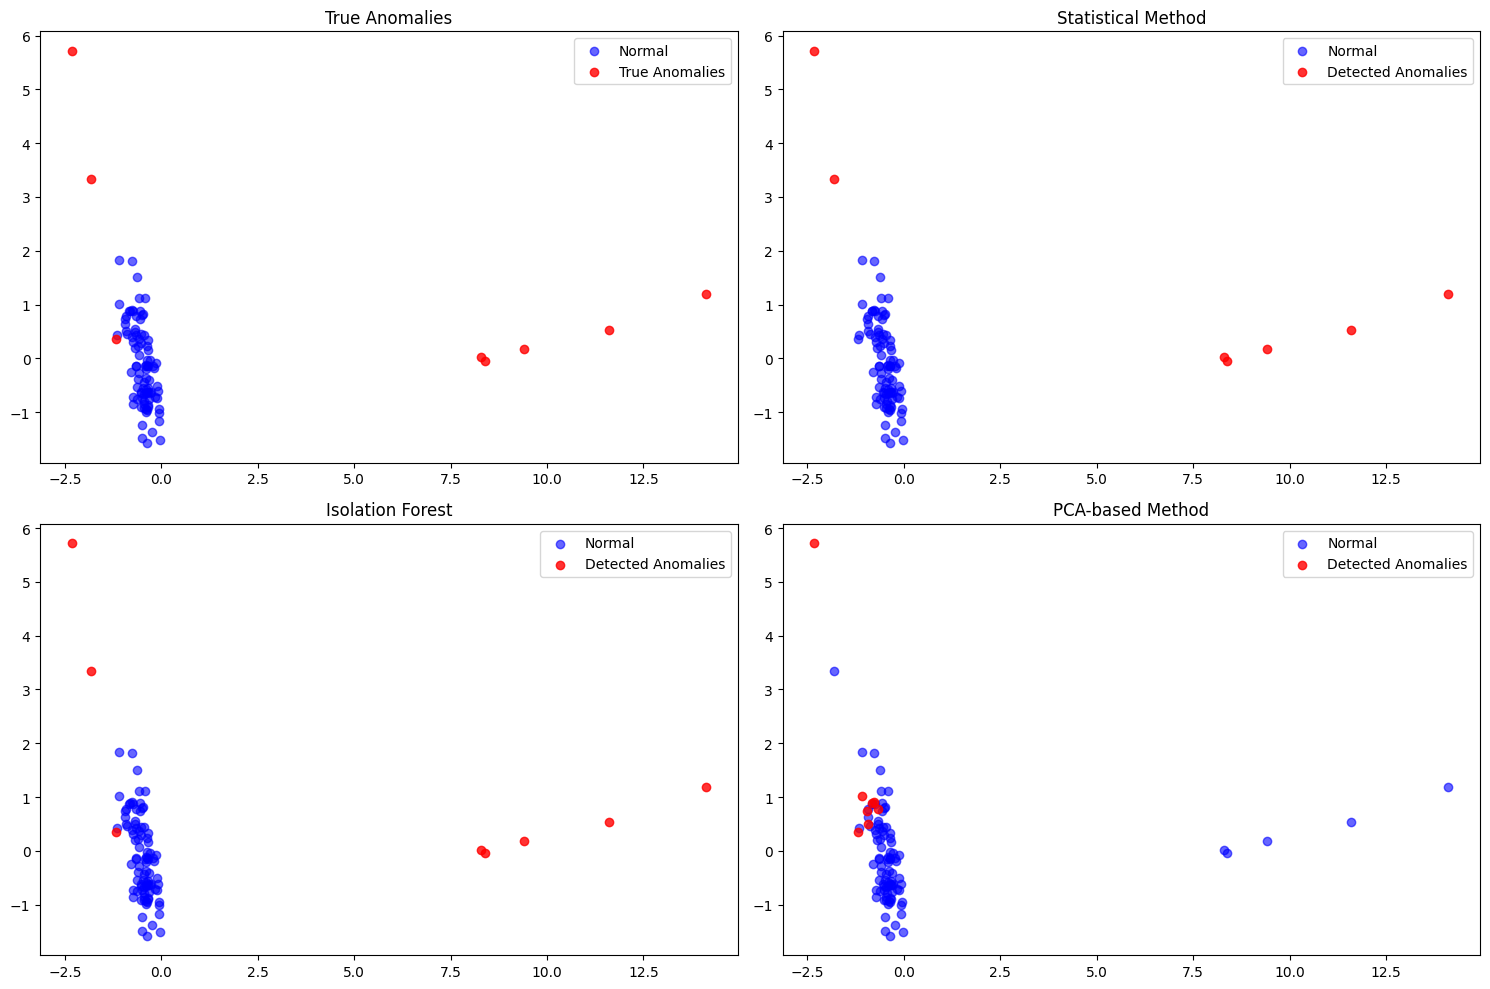

In [9]:
# TODO: Create visualizations to compare methods

# Create a simple visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# True anomalies
axes[0, 0].scatter(df[df['is_anomaly'] == 0]['feature_1'],
                  df[df['is_anomaly'] == 0]['feature_2'],
                  c='blue', label='Normal', alpha=0.6)
axes[0, 0].scatter(df[df['is_anomaly'] == 1]['feature_1'],
                  df[df['is_anomaly'] == 1]['feature_2'],
                  c='red', label='True Anomalies', alpha=0.8)
axes[0, 0].set_title('True Anomalies')
axes[0, 0].legend()

# Statistical method
axes[0, 1].scatter(df[~statistical_anomalies]['feature_1'],
                  df[~statistical_anomalies]['feature_2'],
                  c='blue', label='Normal', alpha=0.6)
axes[0, 1].scatter(df[statistical_anomalies]['feature_1'],
                  df[statistical_anomalies]['feature_2'],
                  c='red', label='Detected Anomalies', alpha=0.8)
axes[0, 1].set_title('Statistical Method')
axes[0, 1].legend()

# Isolation Forest
axes[1, 0].scatter(df[~iso_anomalies]['feature_1'],
                  df[~iso_anomalies]['feature_2'],
                  c='blue', label='Normal', alpha=0.6)
axes[1, 0].scatter(df[iso_anomalies]['feature_1'],
                  df[iso_anomalies]['feature_2'],
                  c='red', label='Detected Anomalies', alpha=0.8)
axes[1, 0].set_title('Isolation Forest')
axes[1, 0].legend()

# PCA-based
axes[1, 1].scatter(df[~pca_anomalies]['feature_1'],
                  df[~pca_anomalies]['feature_2'],
                  c='blue', label='Normal', alpha=0.6)
axes[1, 1].scatter(df[pca_anomalies]['feature_1'],
                  df[pca_anomalies]['feature_2'],
                  c='red', label='Detected Anomalies', alpha=0.8)
axes[1, 1].set_title('PCA-based Method')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Part 5: Reflection and Best Practices

### Step 1: Document Your Learning

**🎯 Critical Thinking Exercise:** Answer these questions to deepen your understanding and connect to real-world applications.

### Reflection Questions

**Consider these questions about your anomaly detection experience:**
1. Which method worked best for your dataset?
2. How did AI-enhanced methods compare to traditional approaches?
3. What challenges did you encounter?
4. How would you validate the results in a real-world scenario?

In [10]:
# TODO: Reflect on your anomaly detection experience

# AI Prompt: "Help me think through these reflection questions. What would a data science manager want to know about my anomaly detection approach?"

### Step 2: Best Practices

### Best Practices for Anomaly Detection

**Key principles to follow:**
1. Always validate results with domain experts
2. Consider the business context when setting thresholds
3. Use multiple methods for robust detection
4. Continuously monitor and update models
5. Document your approach for reproducibility

In [11]:
# TODO: Document best practices for anomaly detection

## Final Reflection: Connecting to Your Career

**🎯 Career Connection:** Anomaly detection skills are highly valued in:
- **Financial Services:** Fraud detection, risk management
- **Cybersecurity:** Intrusion detection, threat analysis  
- **Manufacturing:** Quality control, predictive maintenance
- **Healthcare:** Medical diagnosis, patient monitoring
- **E-commerce:** Recommendation systems, fraud prevention

### Metacognitive Learning Prompts
- **What did you learn about your own learning process?**
- **How would you apply this to a different domain?**
- **What connections do you see to other concepts?**
- **What questions do you still have?**

**Next Steps:** Try applying these techniques to a real dataset from your field of interest. Consider how you would explain your approach to a non-technical stakeholder.

### Transfer Applications
- **How would this work in healthcare?**
- **What would change if you had 10 times more data?**
- **How would you explain this to business executives?**

### Expert Thinking
- **What would an expert do differently?**
- **What assumptions are you making?**
- **How would you validate your approach?**